In [ ]:
!pip install -q numpy==1.26.4
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q simple-lama-inpainting scikit-image
!pip install -q --upgrade pillow
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
simple-lama-inpainting 0.1.2 requires pillow<10.0.0,>=9.5.0, but you have pillow 12.1.1 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Use the standard, unbreakable static backend
%matplotlib inline

import torch, cv2, os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.exposure import match_histograms
from segment_anything import sam_model_registry, SamPredictor
from simple_lama_inpainting import SimpleLama

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth").to(DEVICE)
predictor = SamPredictor(sam)
lama = SimpleLama()

DRIVE_FOLDER = '/content/drive/MyDrive/VenueVision_Assets'
os.makedirs(DRIVE_FOLDER, exist_ok=True)
print(f"Venue Vision Engine Ready on {DEVICE}.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Downloading: "https://github.com/enesmsahin/simple-lama-inpainting/releases/download/v0.1.0/big-lama.pt" to /root/.cache/torch/hub/checkpoints/big-lama.pt
100%|██████████| 196M/196M [00:02<00:00, 91.2MB/s]


Venue Vision Engine Ready on cuda.


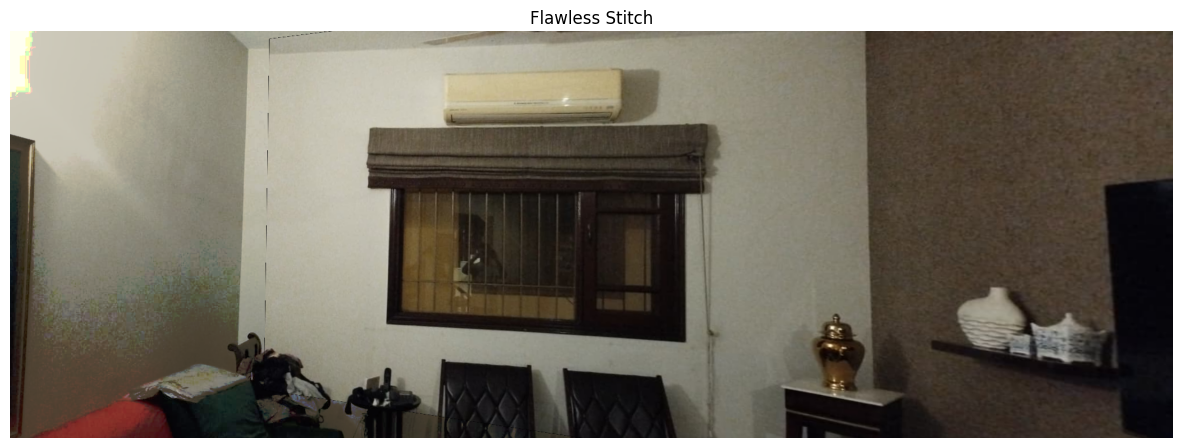

In [ ]:
def flawless_stitch(img_left_path, img_right_path):
    img_left = cv2.imread(img_left_path)
    img_right = cv2.imread(img_right_path)

    # --- ADDED SAFETY CHECK ---
    if img_left is None or img_right is None:
        print("❌ ERROR: Could not find the images!")
        print(f"Please ensure both '{img_left_path}' and '{img_right_path}' are uploaded to the Colab sidebar.")
        return None
    # --------------------------

    img_left_matched = match_histograms(img_left, img_right, channel_axis=-1).astype(np.uint8)
    gray_left = cv2.cvtColor(img_left_matched, cv2.COLOR_BGR2GRAY)
    gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()
    kp_left, des_left = sift.detectAndCompute(gray_left, None)
    kp_right, des_right = sift.detectAndCompute(gray_right, None)

    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des_right, des_left, k=2)

    good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]

    src_pts = np.float32([kp_right[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp_left[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    h_left, w_left = img_left_matched.shape[:2]
    h_right, w_right = img_right.shape[:2]

    panorama = cv2.warpPerspective(img_right, M, (w_left + w_right, h_left))
    right_mask = cv2.warpPerspective(np.ones_like(img_right, dtype=np.uint8)*255, M, (w_left + w_right, h_left))
    panorama[0:h_left, 0:w_left] = np.where(right_mask[0:h_left, 0:w_left] == 0,
                                            img_left_matched,
                                            panorama[0:h_left, 0:w_left])

    gray_pano = cv2.cvtColor(panorama, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray_pano, 1, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        x, y, w, h = cv2.boundingRect(contours[0])
        inset = 5
        final_canvas = panorama[y+inset:y+h-inset, x+inset:x+w-inset]
    else:
        final_canvas = panorama

    output_path = os.path.join(DRIVE_FOLDER, 'flawless_master_wall.png')
    cv2.imwrite(output_path, final_canvas)

    plt.figure(figsize=(15, 8))
    plt.imshow(cv2.cvtColor(final_canvas, cv2.COLOR_BGR2RGB))
    plt.title("Flawless Stitch")
    plt.axis('off')
    plt.show()
    return output_path

merged_path = flawless_stitch('/content/test_wall.jpeg', '/content/test_wall_part2.jpeg')

In [ ]:
import gradio as gr
import cv2
import numpy as np
from PIL import Image
import os

# Setup output path
CLEANED_OUTPUT_PATH = '/content/drive/MyDrive/VenueVision_Assets/cleaned_master_wall.png'

def process_click(image_path, evt: gr.SelectData):
    # evt.index captures the exact [x, y] coordinates of your mouse click!
    x, y = evt.index[0], evt.index[1]
    print(f"Processing removal at X:{x}, Y:{y}...")

    # Load the image fresh from the file path
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    current_img_pil = Image.fromarray(img_rgb)

    # 1. SAM Precise Masking
    predictor.set_image(img_rgb)
    masks, scores, _ = predictor.predict(
        point_coords=np.array([[x, y]]),
        point_labels=np.array([1]),
        multimask_output=True
    )
    mask = masks[np.argmax(scores)].astype(np.uint8) * 255

    # 2. Expand mask for better blending
    mask_dilated = cv2.dilate(mask, np.ones((15, 15), np.uint8), iterations=4)
    mask_pil = Image.fromarray(mask_dilated)

    # 3. LaMa Solid Inpainting
    cleaned_pil = lama(current_img_pil, mask_pil)

    # FIX: Force the image back into standard RGB before saving to strip any weird formatting
    cleaned_pil = cleaned_pil.convert("RGB")
    cleaned_numpy = np.array(cleaned_pil)

    # 4. Save to Drive
    cv2.imwrite(CLEANED_OUTPUT_PATH, cv2.cvtColor(cleaned_numpy, cv2.COLOR_RGB2BGR))
    print("Removal complete! Image updated.")

    # FIX: Return the file path instead of the numpy array so Gradio reads it natively
    return CLEANED_OUTPUT_PATH

# --- Build the Interactive UI ---
with gr.Blocks() as venue_vision_ui:
    gr.Markdown("## 🛋️ VENUE VISION: Tap to Remove")
    gr.Markdown("Click directly on any furniture. The AI will erase it and hallucinate the solid wall behind it.")

    # FIX: type="filepath" bypasses the encoding crash
    img_component = gr.Image(value=merged_path, type="filepath", interactive=False)

    # Link the click event
    img_component.select(process_click, inputs=[img_component], outputs=[img_component])

# Launch the interface
venue_vision_ui.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d41aecaf68db780029.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Processing removal at X:838, Y:626...
Removal complete! Image updated.
Processing removal at X:902, Y:671...
Removal complete! Image updated.
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://d41aecaf68db780029.gradio.live


In [ ]:
import gradio as gr
import cv2
import numpy as np
import os

# Your cleaned image from the previous step
CLEANED_OUTPUT_PATH = '/content/drive/MyDrive/VenueVision_Assets/cleaned_master_wall.png'
# The final 2D texture map for your app
FINAL_ASSET_PATH = '/content/drive/MyDrive/VenueVision_Assets/final_venue_texture.png'

def process_corner_click(image_path, evt: gr.SelectData, points_state):
    x, y = evt.index[0], evt.index[1]
    points_state.append([x, y])
    print(f"Corner recorded at X:{x}, Y:{y}. Total points: {len(points_state)}")

    # Load image to draw visual markers so you can see where you clicked
    img_bgr = cv2.imread(image_path)

    for pt in points_state:
        cv2.circle(img_bgr, (pt[0], pt[1]), 15, (0, 0, 255), -1) # Draw a red dot

    if len(points_state) < 4:
        # Still collecting points: save a temporary image with the red dots
        temp_path = '/content/drive/MyDrive/VenueVision_Assets/temp_corners.png'
        cv2.imwrite(temp_path, img_bgr)

        messages = [
            "Click Top-Left corner",
            "Click Top-Right corner",
            "Click Bottom-Right corner",
            "Click Bottom-Left corner"
        ]
        next_instruction = f"Collected {len(points_state)}/4. Next: {messages[len(points_state)]}"
        return temp_path, points_state, next_instruction

    else:
        # 4 points collected! Perform the perspective warp.
        print("4 corners collected! Flattening wall...")
        pts_src = np.float32(points_state)
        (tl, tr, br, bl) = pts_src

        # Calculate the dimensions of the new flat image
        width = int(max(np.linalg.norm(br-bl), np.linalg.norm(tr-tl)))
        height = int(max(np.linalg.norm(tr-br), np.linalg.norm(tl-bl)))

        pts_dst = np.float32([
            [0, 0],
            [width - 1, 0],
            [width - 1, height - 1],
            [0, height - 1]
        ])

        # We load the ORIGINAL cleaned image here so the red dots don't get saved into your final asset
        orig_bgr = cv2.imread(CLEANED_OUTPUT_PATH)
        M = cv2.getPerspectiveTransform(pts_src, pts_dst)
        warped_asset = cv2.warpPerspective(orig_bgr, M, (width, height))

        cv2.imwrite(FINAL_ASSET_PATH, warped_asset)

        return FINAL_ASSET_PATH, [], "✅ Success! Wall flattened and saved as final texture."

# --- Build the Interactive UI ---
with gr.Blocks(theme=gr.themes.Default()) as corner_ui:
    gr.Markdown("## 📐 VENUE VISION: 4-Point Wall Extractor")
    gr.Markdown("Click the corners of the cleaned wall in order: **TL -> TR -> BR -> BL**.")

    status_text = gr.Markdown("### Collected 0/4. Next: Click Top-Left corner")

    # gr.State acts as memory to hold the coordinates between clicks
    click_state = gr.State([])

    img_component = gr.Image(value=CLEANED_OUTPUT_PATH, type="filepath", interactive=False)

    # Link the click event
    img_component.select(
        process_corner_click,
        inputs=[img_component, click_state],
        outputs=[img_component, click_state, status_text]
    )

    # Add a reset button in case you click the wrong spot
    reset_btn = gr.Button("🔄 Reset Points")
    def reset_state():
        return CLEANED_OUTPUT_PATH, [], "### Collected 0/4. Next: Click Top-Left corner"
    reset_btn.click(reset_state, outputs=[img_component, click_state, status_text])

corner_ui.launch(debug=True)

/tmp/ipykernel_2794/666294631.py:63: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Default()) as corner_ui:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d6cf042943d51355f6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Corner recorded at X:410, Y:42. Total points: 1
Corner recorded at X:442, Y:63. Total points: 2
Corner recorded at X:1486, Y:33. Total points: 3
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://d6cf042943d51355f6.gradio.live
